# Mahmud et al. Xception Reproduction on HAM10000

This notebook reproduces the central classification and explainability idea from Mahmud et al. (ICCIT 2023) using **one model: Xception**. Xception was selected because it achieved the paper's highest reported accuracy, 88.72%.

This is a corrected, compute-conscious reproduction. We keep HAM10000, Xception, 224 x 224 inputs, the paper's classification head, augmentation, and SmoothGrad idea. We change the split to be lesion-safe, stream images instead of loading everything into RAM, use class weights, use stable two-stage fine-tuning, and add clinically meaningful and uncertainty/referral metrics.

**Important:** this notebook is for research and education, not medical diagnosis.


## Before running

1. In Colab select **Runtime -> Change runtime type -> T4 GPU**.
2. In Colab, open the **Secrets** panel using the key icon on the left.
3. Add a secret named `KAGGLE_API_TOKEN`, paste the token Kaggle gave you, and enable notebook access.
4. Run every cell in order.
5. Download the final artifact zip before the Colab session closes.

Expected time on a T4 GPU is roughly 1-3 hours, depending on early stopping and Colab speed.


## 1. Setup and configuration

The fixed seed improves repeatability. Exact GPU results can still vary slightly. The output directory stores evidence from the run.


In [1]:
from __future__ import annotations

import json
import math
import os
import platform
import random
import shutil
import subprocess
import sys
import zipfile
from pathlib import Path

subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', 'kaggle'])

import cv2
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import sklearn
import tensorflow as tf
from sklearn.metrics import (
    accuracy_score, balanced_accuracy_score, classification_report,
    confusion_matrix, f1_score, roc_auc_score,
)
from sklearn.model_selection import StratifiedGroupKFold
from sklearn.utils.class_weight import compute_class_weight

SEED = 42
IMAGE_SIZE = (224, 224)
BATCH_SIZE = 16
HEAD_EPOCHS = 5
FINE_TUNE_EPOCHS = 20
FINE_TUNE_LAYERS = 30
CLASS_NAMES = ['akiec', 'bcc', 'bkl', 'df', 'mel', 'nv', 'vasc']
NUM_CLASSES = len(CLASS_NAMES)
MELANOMA_INDEX = CLASS_NAMES.index('mel')

DATA_ROOT = Path('/content/ham10000')
OUTPUT_ROOT = Path('/content/mahmud_xception_outputs')
OUTPUT_ROOT.mkdir(parents=True, exist_ok=True)
BEST_MODEL_PATH = OUTPUT_ROOT / 'best_xception.keras'

os.environ['PYTHONHASHSEED'] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
tf.keras.utils.set_random_seed(SEED)
try:
    tf.config.experimental.enable_op_determinism()
except Exception as exc:
    print('Deterministic operations could not be fully enabled:', exc)

gpus = tf.config.list_physical_devices('GPU')
print('TensorFlow:', tf.__version__)
print('scikit-learn:', sklearn.__version__)
print('GPU:', gpus if gpus else 'No GPU detected. Training will be slow.')


TensorFlow: 2.20.0
scikit-learn: 1.6.1
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## 2. Download HAM10000

The original repository expects private `data.npy` and `labels.npy` files but does not provide the code that creates them. This cell replaces that missing step by downloading the public HAM10000 Kaggle mirror and locating the images directly. Your Kaggle token is used only inside the current Colab session. Never commit it to GitHub.


In [2]:
metadata_path = DATA_ROOT / 'HAM10000_metadata.csv'

if not metadata_path.exists():
    from google.colab import userdata

    try:
        kaggle_api_token = userdata.get('KAGGLE_API_TOKEN')
    except Exception as exc:
        raise RuntimeError(
            'Add KAGGLE_API_TOKEN in the Colab Secrets panel and enable notebook access.'
        ) from exc
    if not kaggle_api_token:
        raise RuntimeError('The KAGGLE_API_TOKEN secret is empty.')

    kaggle_dir = Path('/root/.kaggle')
    kaggle_dir.mkdir(parents=True, exist_ok=True)
    token_path = kaggle_dir / 'access_token'
    token_path.write_text(kaggle_api_token.strip())
    token_path.chmod(0o600)
    del kaggle_api_token

    DATA_ROOT.mkdir(parents=True, exist_ok=True)
    archive_path = DATA_ROOT / 'ham10000.zip'
    subprocess.check_call([
        'kaggle', 'datasets', 'download',
        '-d', 'kmader/skin-cancer-mnist-ham10000',
        '-p', str(DATA_ROOT),
    ])
    downloaded_archives = list(DATA_ROOT.glob('*.zip'))
    if not downloaded_archives:
        raise FileNotFoundError('Kaggle download completed but no zip file was found.')
    with zipfile.ZipFile(downloaded_archives[0]) as archive:
        archive.extractall(DATA_ROOT)

if not metadata_path.exists():
    candidates = list(DATA_ROOT.rglob('HAM10000_metadata.csv'))
    if not candidates:
        raise FileNotFoundError('HAM10000_metadata.csv was not found after extraction.')
    metadata_path = candidates[0]

print('Metadata:', metadata_path)


Metadata: /content/ham10000/HAM10000_metadata.csv


## 3. Build and audit the image table

We verify the image count, missing files, class counts, and number of unique lesions before training. This is important because HAM10000 contains multiple photographs of some lesions.


In [3]:
metadata = pd.read_csv(metadata_path)
image_files = list(DATA_ROOT.rglob('*.jpg'))
image_lookup = {path.stem: str(path) for path in image_files}
metadata['path'] = metadata['image_id'].map(image_lookup)
metadata['label'] = metadata['dx'].map({name: i for i, name in enumerate(CLASS_NAMES)})

missing_images = int(metadata['path'].isna().sum())
unknown_labels = int(metadata['label'].isna().sum())
print('Rows:', len(metadata))
print('Unique lesions:', metadata['lesion_id'].nunique())
print('JPEG files found:', len(image_files))
print('Missing image paths:', missing_images)
print('Unknown labels:', unknown_labels)
display(metadata['dx'].value_counts().reindex(CLASS_NAMES).rename('images').to_frame())

if len(metadata) != 10015:
    raise ValueError(f'Expected 10,015 metadata rows, found {len(metadata)}.')
if missing_images or unknown_labels:
    raise ValueError('Dataset audit failed. Fix missing images or labels before continuing.')
if (metadata.groupby('lesion_id')['dx'].nunique() > 1).any():
    raise ValueError('At least one lesion_id has conflicting diagnosis labels.')


Rows: 10015
Unique lesions: 7470
JPEG files found: 20030
Missing image paths: 0
Unknown labels: 0


,images
dx,
akiec,327
bcc,514
bkl,1099
df,115
mel,1113
nv,6705
vasc,142


## 4. Create a leakage-safe 80:10:10 split

The paper describes an 80:10:10 split, but the released code first removes 10% for testing and then takes 10% of the remaining data for validation, producing approximately 81:9:10. More importantly, it splits individual images. We group by `lesion_id`, so photographs of the same lesion cannot appear in different splits.


In [4]:
def grouped_fold(frame: pd.DataFrame, n_splits: int) -> tuple[pd.DataFrame, pd.DataFrame]:
    splitter = StratifiedGroupKFold(n_splits=n_splits, shuffle=True, random_state=SEED)
    keep_idx, hold_idx = next(splitter.split(frame, frame['label'], frame['lesion_id']))
    return frame.iloc[keep_idx].copy(), frame.iloc[hold_idx].copy()

train_val_df, test_df = grouped_fold(metadata, n_splits=10)
train_df, val_df = grouped_fold(train_val_df, n_splits=9)

for frame in (train_df, val_df, test_df):
    frame.reset_index(drop=True, inplace=True)

train_lesions = set(train_df['lesion_id'])
val_lesions = set(val_df['lesion_id'])
test_lesions = set(test_df['lesion_id'])
overlaps = {
    'train_val': len(train_lesions & val_lesions),
    'train_test': len(train_lesions & test_lesions),
    'val_test': len(val_lesions & test_lesions),
}
assert all(value == 0 for value in overlaps.values()), overlaps

split_summary = pd.DataFrame({
    'split': ['train', 'validation', 'test'],
    'images': [len(train_df), len(val_df), len(test_df)],
    'unique_lesions': [train_df.lesion_id.nunique(), val_df.lesion_id.nunique(), test_df.lesion_id.nunique()],
})
split_summary['image_percent'] = 100 * split_summary['images'] / len(metadata)
display(split_summary)
print('Lesion overlap audit:', overlaps)

train_df.to_csv(OUTPUT_ROOT / 'train_split.csv', index=False)
val_df.to_csv(OUTPUT_ROOT / 'validation_split.csv', index=False)
test_df.to_csv(OUTPUT_ROOT / 'test_split.csv', index=False)
with open(OUTPUT_ROOT / 'leakage_audit.json', 'w') as file:
    json.dump(overlaps, file, indent=2)


,split,images,unique_lesions,image_percent
0,train,8013,5976,80.009985
1,validation,1010,747,10.084873
2,test,992,747,9.905142


Lesion overlap audit: {'train_val': 0, 'train_test': 0, 'val_test': 0}


## 5. Stream images with `tf.data`

The original notebooks load the complete resized dataset into NumPy arrays. Streaming images from disk uses much less memory and is safer for an 8 GB computer or a free Colab runtime. Augmentation is placed inside the model and runs only during training.


In [5]:
AUTOTUNE = tf.data.AUTOTUNE

def decode_image(path: tf.Tensor, label: tf.Tensor) -> tuple[tf.Tensor, tf.Tensor]:
    image = tf.io.read_file(path)
    image = tf.io.decode_jpeg(image, channels=3)
    image = tf.image.resize(image, IMAGE_SIZE)
    image = tf.cast(image, tf.float32)
    return image, label

def make_dataset(frame: pd.DataFrame, training: bool) -> tf.data.Dataset:
    dataset = tf.data.Dataset.from_tensor_slices((frame['path'].to_numpy(), frame['label'].astype('int32').to_numpy()))
    if training:
        dataset = dataset.shuffle(len(frame), seed=SEED, reshuffle_each_iteration=True)
    dataset = dataset.map(decode_image, num_parallel_calls=AUTOTUNE, deterministic=True)
    dataset = dataset.batch(BATCH_SIZE, drop_remainder=False)
    return dataset.prefetch(AUTOTUNE)

train_ds = make_dataset(train_df, training=True)
val_ds = make_dataset(val_df, training=False)
test_ds = make_dataset(test_df, training=False)

class_weight_values = compute_class_weight(
    class_weight='balanced',
    classes=np.arange(NUM_CLASSES),
    y=train_df['label'].to_numpy(),
)
class_weights = {i: float(weight) for i, weight in enumerate(class_weight_values)}
print('Class weights:', dict(zip(CLASS_NAMES, class_weight_values.round(3))))

sample_images, sample_labels = next(iter(train_ds))
print('Batch image shape:', sample_images.shape)
print('Batch label shape:', sample_labels.shape)


Class weights: {'akiec': np.float64(4.691), 'bcc': np.float64(2.876), 'bkl': np.float64(1.299), 'df': np.float64(12.178), 'mel': np.float64(1.299), 'nv': np.float64(0.212), 'vasc': np.float64(9.701)}
Batch image shape: (16, 224, 224, 3)
Batch label shape: (16,)


## 6. Build the single Xception model

The head matches the released Xception notebook: global average pooling, Dense(128, ReLU), Dropout(0.5), and seven outputs. We replace the old `ImageDataGenerator` with current Keras augmentation layers. Shearing is omitted because current core Keras does not provide an equivalent built-in layer; rotation, translation, zoom, and horizontal flipping are retained.


In [6]:
augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip('horizontal', seed=SEED),
    tf.keras.layers.RandomRotation(20 / 360, seed=SEED),
    tf.keras.layers.RandomTranslation(0.2, 0.2, seed=SEED),
    tf.keras.layers.RandomZoom(0.2, seed=SEED),
], name='training_augmentation')

base_model = tf.keras.applications.Xception(
    weights='imagenet',
    include_top=False,
    input_shape=(*IMAGE_SIZE, 3),
)
base_model.trainable = False

inputs = tf.keras.Input(shape=(*IMAGE_SIZE, 3), name='image')
x = augmentation(inputs)
x = tf.keras.layers.Rescaling(scale=1.0 / 127.5, offset=-1.0, name='xception_preprocess')(x)
x = base_model(x, training=False)
x = tf.keras.layers.GlobalAveragePooling2D(name='global_average_pooling')(x)
x = tf.keras.layers.Dense(128, activation='relu', name='dense_128')(x)
x = tf.keras.layers.Dropout(0.5, name='dropout')(x)
logits = tf.keras.layers.Dense(NUM_CLASSES, name='logits')(x)
outputs = tf.keras.layers.Softmax(name='predictions')(logits)
model = tf.keras.Model(inputs, outputs, name='mahmud_xception_reproduction')

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(),
    metrics=[tf.keras.metrics.SparseCategoricalAccuracy(name='accuracy')],
)
model.summary()


83683744/83683744 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


Model: "mahmud_xception_reproduction"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ image (InputLayer)              │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ training_augmentation           │ (None, 224, 224, 3)    │             0 │
│ (Sequential)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ xception_preprocess (Rescaling) │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ xception (Functional)           │ (None, 7, 7, 2048)     │    20,861,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling          │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_128 (Dense)               │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ logits (Dense)                  │ (None, 7)              │           903 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ predictions (Softmax)           │ (None, 7)              │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 21,124,655 (80.58 MB)

 Trainable params: 263,175 (1.00 MB)

 Non-trainable params: 20,861,480 (79.58 MB)

## 7. Train in two stages

Stage 1 trains only the new classification head. Stage 2 fine-tunes the last 30 Xception layers with a smaller learning rate. This is our stability and compute adaptation; the released notebook fine-tuned the full network at learning rate 0.001.


Epoch 1/5
501/501 ━━━━━━━━━━━━━━━━━━━━ 0s 97ms/step - accuracy: 0.2897 - loss: 1.9319
Epoch 1: val_loss improved from None to 1.29317, saving model to /content/mahmud_xception_outputs/best_xception.keras

Epoch 1: finished saving model to /content/mahmud_xception_outputs/best_xception.keras
501/501 ━━━━━━━━━━━━━━━━━━━━ 68s 115ms/step - accuracy: 0.3518 - loss: 1.7764 - val_accuracy: 0.6010 - val_loss: 1.2932 - learning_rate: 0.0010
Epoch 2/5
501/501 ━━━━━━━━━━━━━━━━━━━━ 0s 110ms/step - accuracy: 0.4250 - loss: 1.5792
Epoch 2: val_loss did not improve from 1.29317
501/501 ━━━━━━━━━━━━━━━━━━━━ 62s 125ms/step - accuracy: 0.4177 - loss: 1.5423 - val_accuracy: 0.4752 - val_loss: 1.4204 - learning_rate: 0.0010
Epoch 3/5
501/501 ━━━━━━━━━━━━━━━━━━━━ 0s 113ms/step - accuracy: 0.4316 - loss: 1.4283
Epoch 3: val_loss did not improve from 1.29317

Epoch 3: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
501/501 ━━━━━━━━━━━━━━━━━━━━ 83s 126ms/step - accuracy: 0.4388 - loss: 1.47

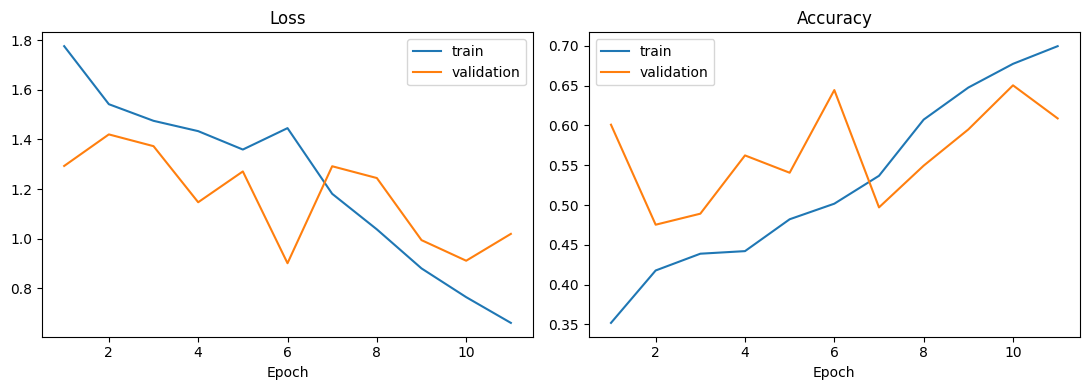

In [7]:
def callbacks() -> list[tf.keras.callbacks.Callback]:
    return [
        tf.keras.callbacks.ModelCheckpoint(
            BEST_MODEL_PATH, monitor='val_loss', mode='min', save_best_only=True, verbose=1
        ),
        tf.keras.callbacks.ReduceLROnPlateau(
            monitor='val_loss', mode='min', factor=0.5, patience=2, min_lr=1e-6, verbose=1
        ),
        tf.keras.callbacks.EarlyStopping(
            monitor='val_loss', mode='min', patience=5, restore_best_weights=True, verbose=1
        ),
    ]

head_history = model.fit(
    train_ds, validation_data=val_ds, epochs=HEAD_EPOCHS,
    class_weight=class_weights, callbacks=callbacks(),
)

model = tf.keras.models.load_model(BEST_MODEL_PATH)
base_model = model.get_layer('xception')
base_model.trainable = True
for layer in base_model.layers[:-FINE_TUNE_LAYERS]:
    layer.trainable = False
for layer in base_model.layers:
    if isinstance(layer, tf.keras.layers.BatchNormalization):
        layer.trainable = False

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(),
    metrics=[tf.keras.metrics.SparseCategoricalAccuracy(name='accuracy')],
)
fine_history = model.fit(
    train_ds, validation_data=val_ds, epochs=FINE_TUNE_EPOCHS,
    class_weight=class_weights, callbacks=callbacks(),
)

model = tf.keras.models.load_model(BEST_MODEL_PATH)
history = {}
for key in set(head_history.history) | set(fine_history.history):
    history[key] = head_history.history.get(key, []) + fine_history.history.get(key, [])
with open(OUTPUT_ROOT / 'training_history.json', 'w') as file:
    json.dump({key: [float(value) for value in values] for key, values in history.items()}, file, indent=2)

epochs_axis = np.arange(1, len(history['loss']) + 1)
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(epochs_axis, history['loss'], label='train')
axes[0].plot(epochs_axis, history['val_loss'], label='validation')
axes[0].set(title='Loss', xlabel='Epoch')
axes[0].legend()
axes[1].plot(epochs_axis, history['accuracy'], label='train')
axes[1].plot(epochs_axis, history['val_accuracy'], label='validation')
axes[1].set(title='Accuracy', xlabel='Epoch')
axes[1].legend()
plt.tight_layout()
plt.savefig(OUTPUT_ROOT / 'training_curves.png', dpi=180, bbox_inches='tight')
plt.show()


## 8. Evaluate the untouched test set

Accuracy is retained for comparison with the paper, but it is not enough for this imbalanced dataset. Balanced accuracy, macro F1, per-class recall, melanoma false-negative rate, AUROC, and calibration error give a more complete result.


In [8]:
def expected_calibration_error(y_true: np.ndarray, probabilities: np.ndarray, bins: int = 15) -> float:
    confidence = probabilities.max(axis=1)
    prediction = probabilities.argmax(axis=1)
    correct = (prediction == y_true).astype(float)
    edges = np.linspace(0.0, 1.0, bins + 1)
    ece = 0.0
    for lower, upper in zip(edges[:-1], edges[1:]):
        in_bin = (confidence > lower) & (confidence <= upper)
        if in_bin.any():
            ece += in_bin.mean() * abs(correct[in_bin].mean() - confidence[in_bin].mean())
    return float(ece)

test_probabilities = model.predict(test_ds, verbose=1)
test_true = test_df['label'].to_numpy()
test_pred = test_probabilities.argmax(axis=1)
test_confidence = test_probabilities.max(axis=1)

melanoma_mask = test_true == MELANOMA_INDEX
melanoma_false_negatives = int(np.sum(melanoma_mask & (test_pred != MELANOMA_INDEX)))
melanoma_total = int(melanoma_mask.sum())
melanoma_recall = 1.0 - melanoma_false_negatives / melanoma_total

metrics = {
    'accuracy': float(accuracy_score(test_true, test_pred)),
    'balanced_accuracy': float(balanced_accuracy_score(test_true, test_pred)),
    'macro_f1': float(f1_score(test_true, test_pred, average='macro')),
    'weighted_f1': float(f1_score(test_true, test_pred, average='weighted')),
    'macro_ovr_auroc': float(roc_auc_score(test_true, test_probabilities, multi_class='ovr', average='macro')),
    'ece_15_bins': expected_calibration_error(test_true, test_probabilities),
    'melanoma_recall': float(melanoma_recall),
    'melanoma_false_negative_rate': float(1.0 - melanoma_recall),
    'melanoma_false_negatives': melanoma_false_negatives,
    'melanoma_test_images': melanoma_total,
}
display(pd.Series(metrics, name='value').to_frame())

report = classification_report(
    test_true, test_pred, labels=np.arange(NUM_CLASSES), target_names=CLASS_NAMES,
    output_dict=True, zero_division=0,
)
report_df = pd.DataFrame(report).T
display(report_df)

with open(OUTPUT_ROOT / 'test_metrics.json', 'w') as file:
    json.dump(metrics, file, indent=2)
report_df.to_csv(OUTPUT_ROOT / 'classification_report.csv')
prediction_table = test_df[['image_id', 'lesion_id', 'dx', 'path']].copy()
prediction_table['predicted_dx'] = [CLASS_NAMES[index] for index in test_pred]
prediction_table['confidence'] = test_confidence
for index, name in enumerate(CLASS_NAMES):
    prediction_table[f'prob_{name}'] = test_probabilities[:, index]
prediction_table.to_csv(OUTPUT_ROOT / 'test_predictions.csv', index=False)


62/62 ━━━━━━━━━━━━━━━━━━━━ 9s 122ms/step


,value
accuracy,0.668347
balanced_accuracy,0.580861
macro_f1,0.420228
weighted_f1,0.690766
macro_ovr_auroc,0.909311
ece_15_bins,0.031683
melanoma_recall,0.423423
melanoma_false_negative_rate,0.576577
melanoma_false_negatives,64.000000
melanoma_test_images,111.000000


,precision,recall,f1-score,support
akiec,0.281250,0.473684,0.352941,38.000000
bcc,0.545455,0.454545,0.495868,66.000000
bkl,0.446809,0.207921,0.283784,101.000000
df,0.118644,0.700000,0.202899,10.000000
mel,0.385246,0.423423,0.403433,111.000000
nv,0.916230,0.806452,0.857843,651.000000
vasc,0.208333,1.000000,0.344828,15.000000
accuracy,0.668347,0.668347,0.668347,0.668347
macro avg,0.414567,0.580861,0.420228,992.000000
weighted avg,0.741285,0.668347,0.690766,992.000000


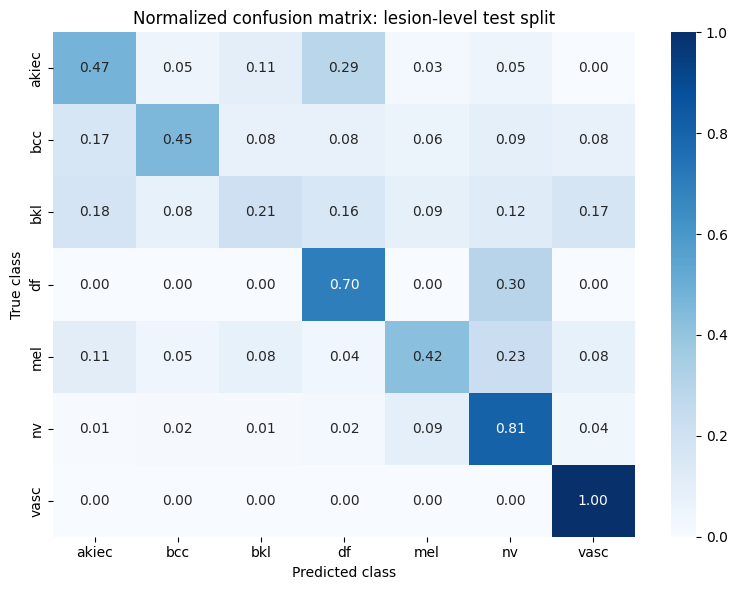

In [9]:
matrix = confusion_matrix(test_true, test_pred, labels=np.arange(NUM_CLASSES), normalize='true')
plt.figure(figsize=(8, 6))
sns.heatmap(matrix, annot=True, fmt='.2f', cmap='Blues', xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
plt.xlabel('Predicted class')
plt.ylabel('True class')
plt.title('Normalized confusion matrix: lesion-level test split')
plt.tight_layout()
plt.savefig(OUTPUT_ROOT / 'confusion_matrix.png', dpi=180, bbox_inches='tight')
plt.show()


## 9. Our uncertainty and referral extension

Mahmud et al. did not evaluate uncertainty. We use normalized predictive entropy as a simple one-model baseline. A higher value means the predicted probability is spread across several classes. Referral thresholds are selected from validation-set entropy, then applied once to the test set. Referral does not make a diagnosis; it means the model declines to automate the most uncertain cases and sends them for human review.


In [10]:
def normalized_entropy(probabilities: np.ndarray) -> np.ndarray:
    safe = np.clip(probabilities, 1e-8, 1.0)
    return -(safe * np.log(safe)).sum(axis=1) / np.log(probabilities.shape[1])

val_probabilities = model.predict(val_ds, verbose=0)
val_entropy = normalized_entropy(val_probabilities)
test_entropy = normalized_entropy(test_probabilities)
prediction_table['normalized_entropy'] = test_entropy
prediction_table.to_csv(OUTPUT_ROOT / 'test_predictions.csv', index=False)

test_error = (test_pred != test_true).astype(int)
error_detection_auroc = roc_auc_score(test_error, test_entropy)
print(f'Entropy AUROC for detecting model errors: {error_detection_auroc:.3f}')

referral_rows = []
for referral_budget in [0.0, 0.10, 0.20, 0.30]:
    threshold = math.inf if referral_budget == 0 else float(np.quantile(val_entropy, 1.0 - referral_budget))
    retained = test_entropy <= threshold
    retained_true = test_true[retained]
    retained_pred = test_pred[retained]
    retained_melanoma = retained_true == MELANOMA_INDEX
    retained_melanoma_count = int(retained_melanoma.sum())
    retained_melanoma_fn = int(np.sum(retained_melanoma & (retained_pred != MELANOMA_INDEX)))
    retained_melanoma_recall = (
        1.0 - retained_melanoma_fn / retained_melanoma_count
        if retained_melanoma_count else float('nan')
    )
    referral_rows.append({
        'target_referral_budget': referral_budget,
        'entropy_threshold_from_validation': threshold,
        'actual_test_referral_rate': float(1.0 - retained.mean()),
        'retained_test_images': int(retained.sum()),
        'retained_accuracy': float(accuracy_score(retained_true, retained_pred)),
        'retained_balanced_accuracy': float(balanced_accuracy_score(retained_true, retained_pred)),
        'retained_macro_f1': float(f1_score(retained_true, retained_pred, average='macro', zero_division=0)),
        'retained_melanoma_images': retained_melanoma_count,
        'retained_melanoma_false_negatives': retained_melanoma_fn,
        'retained_melanoma_recall': retained_melanoma_recall,
    })

referral_results = pd.DataFrame(referral_rows)
display(referral_results)
referral_results.to_csv(OUTPUT_ROOT / 'referral_results.csv', index=False)


Entropy AUROC for detecting model errors: 0.843


,target_referral_budget,entropy_threshold_from_validation,actual_test_referral_rate,retained_test_images,retained_accuracy,retained_balanced_accuracy,retained_macro_f1,retained_melanoma_images,retained_melanoma_false_negatives,retained_melanoma_recall
0,0.0,inf,0.000000,992,0.668347,0.580861,0.420228,111,64,0.423423
1,0.1,0.899349,0.107863,885,0.716384,0.596764,0.454770,98,53,0.459184
2,0.2,0.830117,0.198589,795,0.758491,0.612749,0.482224,81,38,0.530864
3,0.3,0.759590,0.314516,680,0.819118,0.634134,0.542231,62,26,0.580645


## 10. SmoothGrad explanations

The paper used SmoothGrad with Xception. We generate one explanation for a correct prediction and one for a mistake. The heatmap indicates input sensitivity, not medical reasoning, and must not be treated as proof that the model found the lesion for the correct reason.


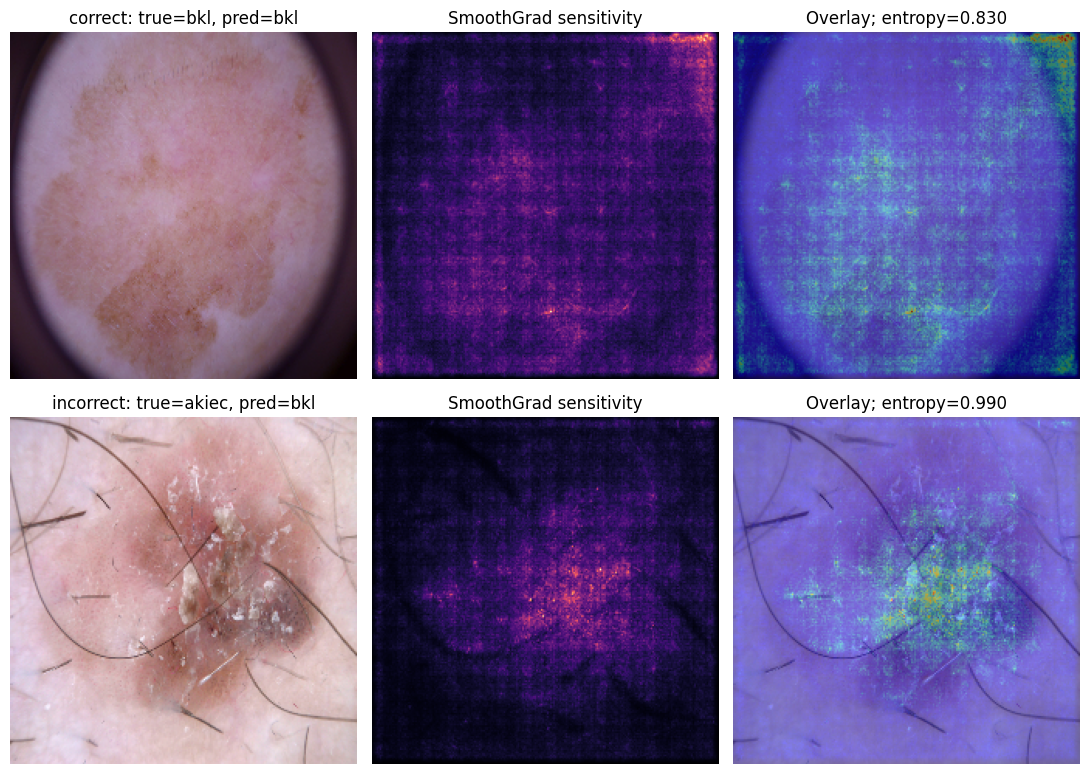

In [11]:
logit_model = tf.keras.Model(model.inputs, model.get_layer('logits').output)

def load_display_image(path: str) -> np.ndarray:
    image = cv2.cvtColor(cv2.imread(path), cv2.COLOR_BGR2RGB)
    return cv2.resize(image, IMAGE_SIZE).astype('float32')

def smoothgrad(image: np.ndarray, class_index: int, samples: int = 20, noise_std: float = 10.0) -> np.ndarray:
    gradients = []
    for _ in range(samples):
        noisy = np.clip(image + np.random.normal(0, noise_std, image.shape), 0, 255).astype('float32')
        tensor = tf.convert_to_tensor(noisy[None, ...])
        with tf.GradientTape() as tape:
            tape.watch(tensor)
            score = logit_model(tensor, training=False)[:, class_index]
        gradient = tape.gradient(score, tensor)[0]
        gradients.append(tf.abs(gradient).numpy())
    saliency = np.mean(gradients, axis=0).max(axis=-1)
    saliency -= saliency.min()
    return saliency / (saliency.max() + 1e-8)

correct_indices = np.flatnonzero(test_pred == test_true)
error_indices = np.flatnonzero(test_pred != test_true)
chosen = [('correct', int(correct_indices[0]))]
if len(error_indices):
    chosen.append(('incorrect', int(error_indices[np.argmax(test_entropy[error_indices])])))

fig, axes = plt.subplots(len(chosen), 3, figsize=(11, 4 * len(chosen)))
axes = np.atleast_2d(axes)
for row, (case_name, index) in enumerate(chosen):
    image = load_display_image(test_df.iloc[index]['path'])
    predicted_class = int(test_pred[index])
    heatmap = smoothgrad(image, predicted_class)
    axes[row, 0].imshow(image.astype('uint8'))
    axes[row, 0].set_title(f'{case_name}: true={CLASS_NAMES[test_true[index]]}, pred={CLASS_NAMES[predicted_class]}')
    axes[row, 1].imshow(heatmap, cmap='magma')
    axes[row, 1].set_title('SmoothGrad sensitivity')
    axes[row, 2].imshow(image.astype('uint8'))
    axes[row, 2].imshow(heatmap, cmap='jet', alpha=0.45)
    axes[row, 2].set_title(f'Overlay; entropy={test_entropy[index]:.3f}')
    for axis in axes[row]:
        axis.axis('off')
plt.tight_layout()
plt.savefig(OUTPUT_ROOT / 'smoothgrad_examples.png', dpi=180, bbox_inches='tight')
plt.show()


## 11. Save the complete reproduction evidence

The version file, split files, predictions, metrics, figures, and trained checkpoint make the experiment auditable. Download the zip produced below.


In [12]:
versions = {
    'python': platform.python_version(),
    'tensorflow': tf.__version__,
    'numpy': np.__version__,
    'pandas': pd.__version__,
    'scikit_learn': sklearn.__version__,
    'opencv': cv2.__version__,
    'seed': SEED,
}
with open(OUTPUT_ROOT / 'versions.json', 'w') as file:
    json.dump(versions, file, indent=2)

archive = shutil.make_archive('/content/mahmud_xception_reproduction', 'zip', OUTPUT_ROOT)
print('Saved artifact bundle:', archive)
print('Download it from the Colab Files panel before the runtime closes.')


Saved artifact bundle: /content/mahmud_xception_reproduction.zip
Download it from the Colab Files panel before the runtime closes.


## Exercise and interpretation

Before changing the model, answer these questions from your saved results:

1. Which class has the lowest recall?
2. Is the weighted F1 much higher than macro F1? If yes, the majority classes are hiding weaker minority performance.
3. Does entropy detect errors with AUROC above 0.5?
4. At which referral budget are the fewest melanoma false negatives left in the automated cases?
5. Does SmoothGrad focus on the lesion or on borders, rulers, hair, and background artifacts?


In [13]:
# Answer scaffold: this prints the first facts needed for your discussion.
class_rows = report_df.loc[CLASS_NAMES].sort_values('recall')
print('Lowest-recall class:', class_rows.index[0], 'recall =', round(class_rows.iloc[0]['recall'], 3))
print('Weighted F1:', round(metrics['weighted_f1'], 3))
print('Macro F1:', round(metrics['macro_f1'], 3))
print('Entropy error-detection AUROC:', round(error_detection_auroc, 3))
display(referral_results[['target_referral_budget', 'actual_test_referral_rate', 'retained_melanoma_false_negatives', 'retained_melanoma_recall']])


Lowest-recall class: bkl recall = 0.208
Weighted F1: 0.691
Macro F1: 0.42
Entropy error-detection AUROC: 0.843


,target_referral_budget,actual_test_referral_rate,retained_melanoma_false_negatives,retained_melanoma_recall
0,0.0,0.000000,64,0.423423
1,0.1,0.107863,53,0.459184
2,0.2,0.198589,38,0.530864
3,0.3,0.314516,26,0.580645
